# EDA — Exploratory Data Analysis

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_all
from src.config import FIGURES

sns.set_theme(style="whitegrid")
FIGURES.mkdir(parents=True, exist_ok=True)

# Data Overview

In [ ]:
df = load_all()
print(f"Total data: {df.shape[0]} tweets, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head(10)

[filter_cs_replies] Dropped 1 CS reply tweets by username
[filter_spam] Dropped 211 spam/foreign tweets
[drop_duplicates] Dropped 946 duplicate tweets
Total data: 4842 tweets, 5 columns
Columns: ['source', 'provider', 'date', 'username', 'tweet_raw']


/home/muba/Work/Projects/sentimen-analisis-telekomunikasi-indonesia/notebooks/../src/data_loader.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['tweet_raw'].str.contains(pattern, case=False, na=False, regex=True)


,source,provider,date,username,tweet_raw
0,playstore,telkomsel,2026-05-23 21:38:16,reevan Silalahi,halo Telkomsel kenapa kalau PLN mati jaringan ...
1,playstore,telkomsel,2026-05-23 21:37:11,Aloysius Riberu,bagus
2,playstore,telkomsel,2026-05-23 21:36:26,George Michael,oi bisa ga si jaringan lu tiap malam ga ngeleg...
3,playstore,telkomsel,2026-05-23 21:36:04,BP MUDA,telkomsel skarang leletnya minta ampun. mw buk...
4,playstore,telkomsel,2026-05-23 21:33:20,miz Gaming,layanan dan promonya terbaik pertahankan min
5,playstore,telkomsel,2026-05-23 21:25:49,Yeyen Vhyno,makin lama makin kesini beli paket telkomsel m...
6,playstore,telkomsel,2026-05-23 21:23:40,FYS S17,ini daerah galaksi Telkomsel jelek banget siny...
7,playstore,telkomsel,2026-05-23 21:20:21,Gerakan pencari Nafkah,aku tak pernah dapat hadiah
8,playstore,telkomsel,2026-05-23 21:18:12,Junk Ari,jaringannya tidak stabil blakangan ini dari mi...
9,playstore,telkomsel,2026-05-23 21:17:45,ito cornering,"aplikasi sering error, ga ada notif tau tau ku..."


# Distribusi Data per Provider

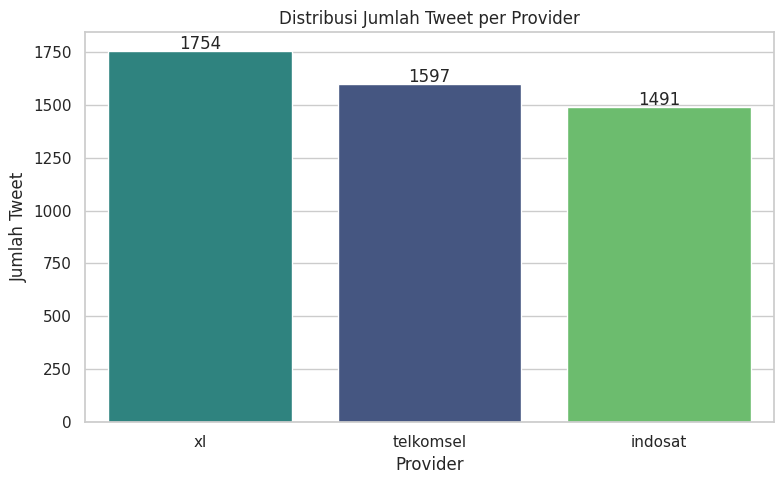

Tabel Distribusi Provider:


,Count,Percentage (%)
provider,,
xl,1754,36.22
telkomsel,1597,32.98
indosat,1491,30.79


In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='provider',
    hue='provider',
    palette='viridis',
    order=df['provider'].value_counts().index,
    legend=False
)
plt.title('Distribusi Jumlah Tweet per Provider')
plt.xlabel('Provider')
plt.ylabel('Jumlah Tweet')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES / "01_distribusi_provider.png")
plt.show()

print("Tabel Distribusi Provider:")
counts = df['provider'].value_counts()
percentages = df['provider'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
display(dist_df)

# Distribusi Data per Sumber

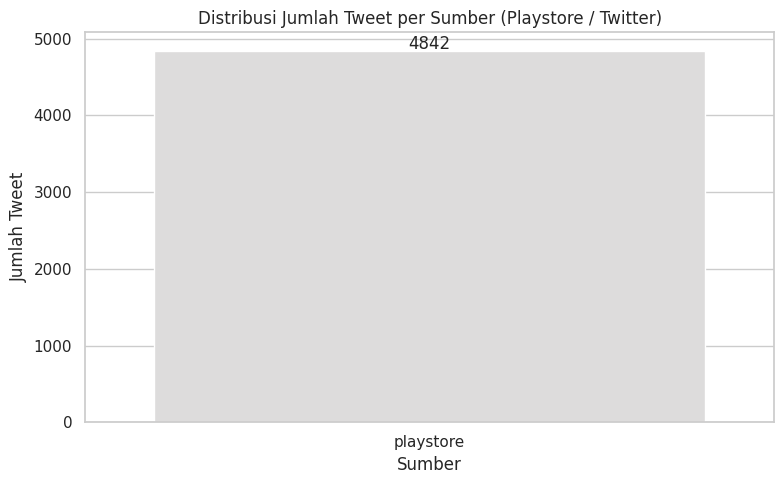

Tabel Distribusi Sumber:


,Count,Percentage (%)
source,,
playstore,4842,100.0


In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='source',
    hue='source',
    palette='coolwarm',
    order=df['source'].value_counts().index,
    legend=False
)
plt.title('Distribusi Jumlah Tweet per Sumber (Playstore / Twitter)')
plt.xlabel('Sumber')
plt.ylabel('Jumlah Tweet')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES / "01_distribusi_sumber.png")
plt.show()

print("Tabel Distribusi Sumber:")
src_counts = df['source'].value_counts()
src_pct = df['source'].value_counts(normalize=True) * 100
src_df = pd.DataFrame({'Count': src_counts, 'Percentage (%)': src_pct.round(2)})
display(src_df)

# Analisis Panjang Tweet

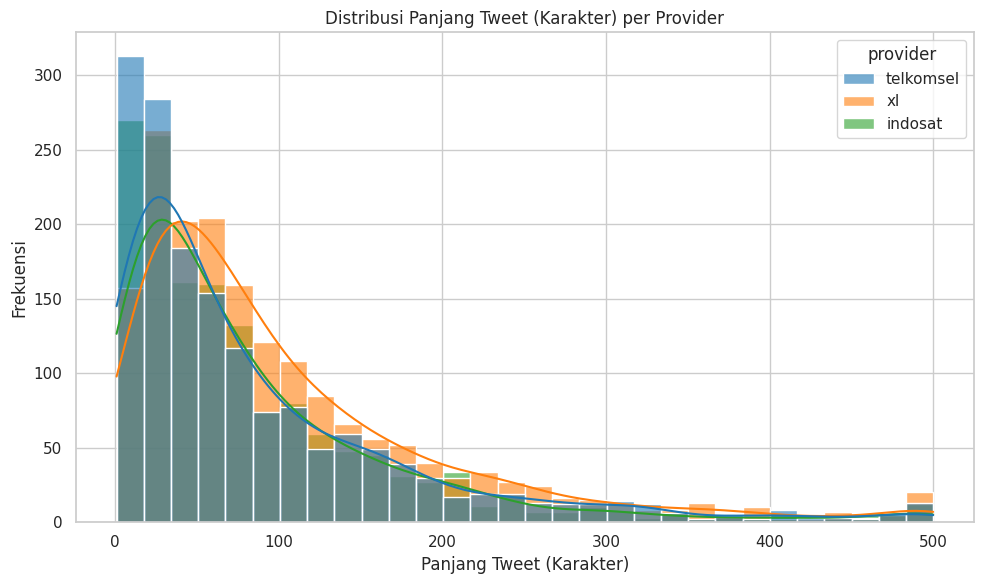

Statistik Deskriptif Panjang Tweet per Provider:


,mean,median,min,max
provider,,,,
indosat,85.18,56.0,1,500
telkomsel,86.48,52.0,1,500
xl,104.44,72.0,1,500


In [ ]:
df['tweet_length'] = df['tweet_raw'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tweet_length', hue='provider', bins=30, kde=True, palette='tab10', alpha=0.6)
plt.title('Distribusi Panjang Tweet (Karakter) per Provider')
plt.xlabel('Panjang Tweet (Karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig(FIGURES / "01_distribusi_panjang_tweet.png")
plt.show()

print("Statistik Deskriptif Panjang Tweet per Provider:")
display(df.groupby('provider')['tweet_length'].agg(['mean', 'median', 'min', 'max']).round(2))

# Analisis Missing Values

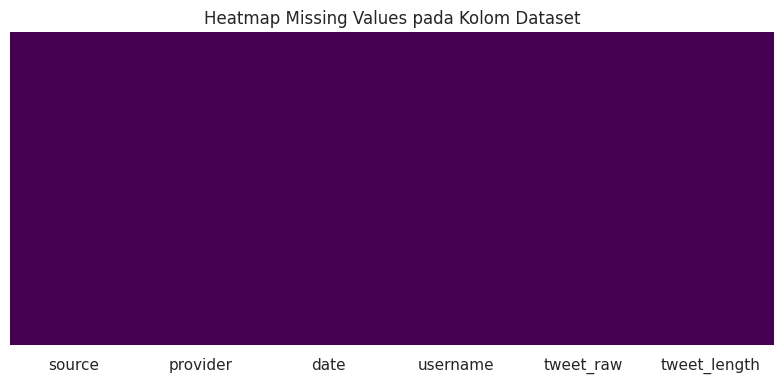

Jumlah Missing Values per Kolom:


source          0
provider        0
date            0
username        0
tweet_raw       0
tweet_length    0
dtype: int64

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Heatmap Missing Values pada Kolom Dataset')
plt.tight_layout()
plt.savefig(FIGURES / "01_missing_values.png")
plt.show()

print("Jumlah Missing Values per Kolom:")
display(df.isnull().sum())

# Sample Tweet Inspection per Provider

In [ ]:
with pd.option_context('display.max_colwidth', None):
    for provider in df['provider'].unique():
        print(f"\n{'='*50}")
        print(f"[{provider.upper()}] - 5 Sample Tweets")
        print(f"{'='*50}")
        sample_tweets = df[df['provider'] == provider]['tweet_raw'].head(5)
        for i, tweet in enumerate(sample_tweets, 1):
            print(f"{i}. {tweet}\n")


[TELKOMSEL] - 5 Sample Tweets
1. halo Telkomsel kenapa kalau PLN mati jaringan Telkomsel juga mati? kendala nya apa ya? sudah sering sekali seperti itu, sementara provider lain kalau PLN mati jaringan nya tetap ada.

2. bagus

3. oi bisa ga si jaringan lu tiap malam ga ngeleg gw mau push renk ajgg

4. telkomsel skarang leletnya minta ampun. mw buka aplikasi telkomsel sndri aja lama bngt apalgi mw hubungi cs telkomsel. sulit dan lelet bngt. terpaksa ku hapus aplikasi telkomsel berat bngt di gunnakan. loading trs

5. layanan dan promonya terbaik pertahankan min


[XL] - 5 Sample Tweets
1. ilang ilang heh

2. ini xl ada apa sih lelet banget. pindah kartu lain ajah ah yg lebih lancar jaringannya

3. WOYY XL PERBAIKI SINYALLL LUU, XL PRIORITAS TAPI SINYAL AMPASSSS

4. mahal semua, jaringan putus², beli paket yg 14 gb malah di kasih 9gb.

5. Paket 5G Quota masih banyak dan masih aktif,kenapa tidak ada sinyal sambungan internetnya?nggak ada pemberitahuan juga?


[INDOSAT] - 5 Sample Tweets
1